We try here to learn the **compositional tensor** with the a *gradient descent*.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

In [73]:
from ctt.bases import make_fourier, make_canonical_polynomials

d = 5
n_features = 2
# basis = make_fourier(dim=n_features, domain=(-3.0, 3.0))
basis = make_canonical_polynomials(n_features)
# basis = lambda x: jnp.array([1.0, x, jnp.abs(x)])
bases = [basis] * (d + 1)

In [74]:
key = random.PRNGKey(42)
cov = random.normal(key=key, shape=(d,d))
cov = cov @ cov.T

In [75]:
@jax.jit
def target(x: Float[Array, "d"]) -> float:
    # return jax.scipy.stats.multivariate_normal.pdf(
    #     x, mean=jnp.zeros_like(x), cov=cov
    # )
    return 1./(1+jnp.mean(x))

In [76]:
from ctt.tt import TT, tt_matvec

def _ftt(x: Float[Array, "d"], tt: TT) -> Float[Array, "d"]:
    features = [bases[i](x[i]) for i in range(x.shape[0])]  # (m,)*d
    result = tt_matvec(tt, features)  # (d, 1)
    return result[:, 0]

@jax.jit
def ctt(tts: list[TT], x: Float[Array, "d"]) -> Float[Array, "d"]:

    def _body_fn(i: int, val: Float[Array, "d"]) -> Float[Array, "d"]:
        control = jax.lax.switch(i, [lambda u=u: u for u in tts])
        return val + _ftt(val, control)
    
    result = jax.lax.fori_loop(0, len(tts), _body_fn, x)
    return result

In [87]:
key, train_key, test_key = random.split(key, 3)

N_train = 3000
# X_train = random.normal(key=train_key, shape=(N_train, d))
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=0., maxval=1.)
y_train = jax.vmap(target)(X_train)
X_train = jnp.concatenate((jnp.ones((N_train, 1)), X_train), axis=1)
y_train = jnp.concatenate((y_train[:, None], X_train[:, 1:]), axis=1)

N_test = 1000
# X_test = random.normal(key=test_key, shape=(N_test, d))
X_test = random.uniform(key=test_key, shape=(N_test, d), minval=0., maxval=1.)
y_test = jax.vmap(target)(X_test)
X_test = jnp.concatenate((jnp.ones((N_test, 1)), X_test), axis=1)
y_test = jnp.concatenate((y_test[:, None], X_test[:, 1:]), axis=1)

num_steps = 5
regularization_coeff = 0.
radius = None
ranks = [d + 1] + [2] * (d) + [1]

In [88]:
import optax
from ctt.tt import tt_norm

learning_rate = 5e-3
# optimizer = optax.amsgrad(learning_rate=learning_rate)
optimizer = optax.adam(learning_rate=learning_rate)

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d"],
                 alpha: float = 0.) -> float:
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    penalty = alpha*jnp.sum(jnp.asarray([tt_norm(u)**2 for u in tts]))
    # penalty = 0.
    return loss + penalty

@jax.jit
def step(tts, opt_state, x, y, alpha=0.):
    loss_value, grads = jax.value_and_grad(compute_loss)(tts, x, y, alpha)
    updates, opt_state = optimizer.update(grads, opt_state, tts)
    params = optax.apply_updates(tts, updates)
    return params, opt_state, loss_value

In [89]:
from ctt.tt import tt_zeros, tt_randn

control_keys = random.split(key, num=num_steps)
params = [
    tt_randn(control_key, [n_features] * (d + 1), ranks, cov=1.)
    for control_key in control_keys
    # tt_zeros([n_features] * (d + 1), ranks)
    # for _ in control_keys
]
optimization_steps = 5000
opt_state = optimizer.init(params)
losses = []
val_losses = []
batch_size = 64
for i in range(optimization_steps):
    start_idx = i*batch_size % N_train
    stop_idx = (i+1)*batch_size % N_train
    params, opt_state, loss_value = step(params, 
                                         opt_state, 
                                         X_train[start_idx:stop_idx], 
                                         y_train[start_idx:stop_idx], 
                                         alpha=regularization_coeff)
    # params, opt_state, loss_value = step(params,
    #                                      opt_state,
    #                                      X_train,
    #                                      y_train,
    #                                      alpha=regularization_coeff)
    test_loss = compute_loss(params, X_test, y_test, alpha=0.)
    losses.append(loss_value)
    val_losses.append(test_loss)
    if i % 5 == 0:
        print(f"Iter {i} | Loss: {loss_value:.3e} | Test loss: {test_loss:.3e}")

losses = jnp.asarray(losses)
val_losses = jnp.asarray(val_losses)

Iter 0 | Loss: 9.019e-03 | Test loss: 9.366e-03
Iter 5 | Loss: 9.358e-03 | Test loss: 9.325e-03
Iter 10 | Loss: 8.636e-03 | Test loss: 9.171e-03
Iter 15 | Loss: 9.319e-03 | Test loss: 8.705e-03
Iter 20 | Loss: 7.515e-03 | Test loss: 7.470e-03
Iter 25 | Loss: 5.537e-03 | Test loss: 4.699e-03
Iter 30 | Loss: 1.412e-03 | Test loss: 7.909e-04
Iter 35 | Loss: 1.676e-03 | Test loss: 1.920e-03
Iter 40 | Loss: 6.072e-04 | Test loss: 4.348e-04
Iter 45 | Loss: 4.430e-04 | Test loss: 5.184e-04
Iter 50 | Loss: 6.413e-04 | Test loss: 5.863e-04
Iter 55 | Loss: 3.327e-04 | Test loss: 2.298e-04
Iter 60 | Loss: 2.497e-04 | Test loss: 3.327e-04
Iter 65 | Loss: 3.363e-04 | Test loss: 2.054e-04
Iter 70 | Loss: 1.745e-04 | Test loss: 1.817e-04
Iter 75 | Loss: 1.430e-04 | Test loss: 1.633e-04
Iter 80 | Loss: 1.011e-04 | Test loss: 1.231e-04
Iter 85 | Loss: 7.938e-05 | Test loss: 1.258e-04
Iter 90 | Loss: 1.233e-04 | Test loss: 9.732e-05
Iter 95 | Loss: 9.295e-05 | Test loss: 9.758e-05
Iter 100 | Loss: 8.350

Text(0, 0.5, 'Loss')

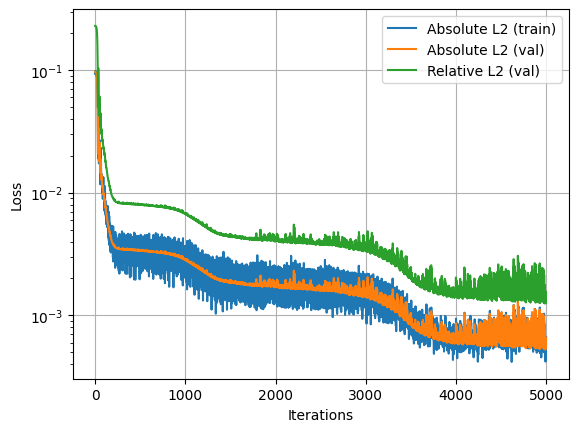

In [90]:
plt.semilogy(jnp.sqrt(losses), label="Absolute L2 (train)")
plt.semilogy(jnp.sqrt(val_losses), label="Absolute L2 (val)")
plt.semilogy(jnp.sqrt(val_losses/jnp.mean(optax.l2_loss(jnp.zeros_like(y_test), y_test))), label="Relative L2 (val)")
plt.grid()
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Loss")

In [91]:
norms = [tt_norm(params[i]).item() for i in range(num_steps)]
print("Norms:", norms)

Norms: [0.1929808322990965, 0.03808494720432176, 0.052497002930436236, 0.03649650901134067, 0.01753543823137366]


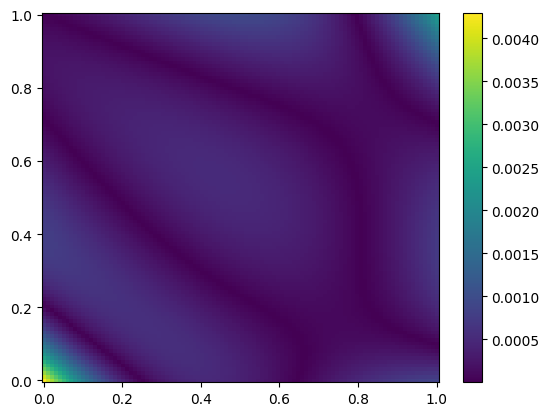

In [ ]:
t = jnp.linspace(0., 1., num=100)
grid = jnp.meshgrid(t, t)
points = jnp.vstack((grid[0].ravel(), grid[1].ravel())).T
tmp_points = jnp.concatenate((jnp.ones((points.shape[0], 1)), points), axis=1)
y_true = jax.vmap(target)(points)
y_pred = jax.vmap(ctt, in_axes=(None, 0))(params, tmp_points)[:, 0]
error = jnp.abs(y_true - y_pred)
error = error.reshape(grid[0].shape)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(grid[0], grid[1], error, cmap="viridis")
fig.colorbar(pcm)